# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV, LassoCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, mean_squared_error, r2_score

# Data Import

## Scraping Data

In [ ]:
# https://developer.clashroyale.com
import requests

# Ask Aiden for Token or IP help
TOKEN = ''
URL = "https://api.clashroyale.com/v1/cards" # change url ending for different data

headers = {
    "Authorization": f"Bearer {TOKEN}",
    "Accept": "application/json"
}

def get_cards_to_csv():
    try:
        # Request data from API
        response = requests.get(URL, headers=headers)
        
        # Check if the request was successful
        if response.status_code == 200:
            data = response.json()
            
            # Convert the 'items' list into a DataFrame
            df = pd.json_normalize(data['items'])
            
            print("Successfully retrieved card data.")
            return df # Preview the first few rows
            
        else:
            print(f"Failed to fetch data. Status Code: {response.status_code}")
            print(f"Error Message: {response.text}")
            
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    ClashRoyaleAPI_cards_df = get_cards_to_csv()

ClashRoyaleAPI_cards_df.columns

## Card Data

In [15]:
cards_df = pd.read_csv('./data/cards_merged.csv')
cards_df.head()

,name,id,maxEvolutionLevel,elixirCost,rarity,damage11,hitpoints,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,3.0,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,1.0,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,2.0,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,2.0,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,1.0,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


## Deck Data

In [28]:
decks_df = pd.read_csv('./data/decks.csv')
decks_df.head()

,card1,card2,card3,card4,card5,card6,card7,card8,wild,usage,Win Rate
0,Lumberjack,Balloon,Executioner,Skeleton Army,Skeletons,Freeze,The Log,Cannon,"['evo', 'hero', 'evo']",0.7,67.7
1,Battle Ram,Wizard,Royal Ghost,Giant Skeleton,Mother Witch,Vines,Zappies,Barbarian Barrel,"['evo', 'hero', 'evo']",0.5,67.6
2,Mortar,Goblins,Minion Horde,Miner,Cannon Cart,Skeleton Dragons,Rascals,Arrows,"['evo', 'hero', 'evo']",0.8,63.6
3,Skeleton Barrel,Goblins,Mortar,Cannon Cart,Fireball,Minions,Rascals,Barbarian Barrel,"['evo', 'hero', 'evo']",4.7,63.3
4,Skeleton Barrel,Bowler,Mortar,Fireball,Dart Goblin,Rascals,Skeletons,Barbarian Barrel,"['evo', 'hero', 'evo']",0.7,63.2


## Counting Null Values

In [16]:
cards_clean_df = cards_df.copy()
cards_df.isnull().sum()

name                  0
id                    0
maxEvolutionLevel    73
elixirCost            1
rarity                0
damage11             29
hitpoints            20
type                  1
mobility              1
targets               1
attack_type           2
groupCard             1
usage                 2
Win Rate              2
dtype: int64

### `maxEvolutionLevel`

In [17]:
cards_clean_df.rename(columns={'maxEvolutionLevel': 'wild'}, inplace=True)
cards_clean_df['wild'] = cards_df['maxEvolutionLevel'].replace({np.nan: 'normal', 1: 'evo', 2: 'hero', 3: 'both'})
cards_clean_df.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


In [10]:
cards_clean_df['wild'].isnull().sum()

np.int64(0)

### `damage11` and `hitpoints`

In [18]:
cards_df.loc[(cards_df['damage11'].isnull()) | (cards_df['hitpoints'].isnull())].head()

,name,id,maxEvolutionLevel,elixirCost,rarity,damage11,hitpoints,type,mobility,targets,attack_type,groupCard,usage,Win Rate
31,Fire Spirit,26000031,NaN,1.0,common,NaN,230.0,troop,ground,ground,single,False,1.76,51.20
64,Firecracker,26000064,1.0,3.0,common,NaN,304.0,troop,ground,both,splash,False,8.08,50.15
65,Mighty Miner,26000065,NaN,4.0,champion,NaN,2250.0,troop,ground,ground,single,False,4.24,57.00
67,Battle Healer,26000068,NaN,4.0,rare,NaN,1717.0,troop,flying,ground,single,False,1.44,56.07
68,Skeleton King,26000069,NaN,4.0,champion,NaN,2298.0,troop,ground,ground,splash,False,3.68,57.40


These missing values can be replaced manually using domain knowledge. Missing `hitpoints` values primarily belong to spell-type cards, which lack health in the original game.

In [19]:
cards_clean_df.rename(columns = {'hitpoints': 'hitpoints11'}, inplace = True)
cards_clean_df.loc[31, 'damage11'] = 207
cards_clean_df.loc[64, 'damage11'] = 320
cards_clean_df.loc[65, 'damage11'] = 40
cards_clean_df.loc[67, 'damage11'] = 148
cards_clean_df.loc[68, 'damage11'] = 204
cards_clean_df.loc[69, 'damage11'] = 225
cards_clean_df.loc[70, 'damage11'] = 161
cards_clean_df.loc[71, 'damage11'] = 140
cards_clean_df.loc[72, 'damage11'] = 161
cards_clean_df.loc[73, 'damage11'] = 133
cards_clean_df.loc[74, 'damage11'] = 99
cards_clean_df.loc[75, 'damage11'] = 163
cards_clean_df.loc[76, 'damage11'] = 217
cards_clean_df.loc[77, 'damage11'] = 104
cards_clean_df.loc[78, 'damage11'] = 186
cards_clean_df.loc[79, 'damage11'] = 212
cards_clean_df.loc[80, 'damage11'] = 256
cards_clean_df.loc[81, 'damage11'] = 128
cards_clean_df.loc[82, 'damage11'] = 120
cards_clean_df.loc[83, 'damage11'] = 102
cards_clean_df.loc[84, 'damage11'] = 245
cards_clean_df.loc[97, 'damage11'] = 120
cards_clean_df.loc[100, 'damage11'] = 179
cards_clean_df.loc[111, 'damage11'] = 0
cards_clean_df.loc[114, 'damage11'] = 110
cards_clean_df.loc[116, 'damage11'] = 437
cards_clean_df.loc[117, 'damage11'] = 1020
cards_clean_df.loc[118, 'damage11'] = 210
cards_clean_df.loc[119, 'damage11'] = 307
cards_clean_df.loc[120, 'damage11'] = 306
cards_clean_df.loc[114, 'type'] = 'troop'
cards_clean_df.loc[119, 'hitpoints11'] = 1177
cards_clean_df['damage11'].isnull().sum()

np.int64(0)

### Unique Missing Values

Card 104 is the unique Mirror card. Its values cannot be easily replaced, so we omitted it during analysis. Cards 119 and 120 are the Spirit Empress and Vines cards, which were added too recently to be included in the Kaggle datasets we used. Their values were added manually.

In [24]:
cards_clean_df.loc[119, ['type', 'mobility', 'targets', 'attack_type', 'groupCard', 'usage', 'Win Rate']] = ['troop', 'flying', 'both', 'single', 'False', 4.80, 54.23]
cards_clean_df.loc[120, ['usage', 'Win Rate']] = [4.80, 53.21]
cards_clean_df.drop(104).isnull().sum()

name            0
id              0
wild            0
elixirCost      0
rarity          0
damage11        0
hitpoints11    18
type            0
mobility        0
targets         0
attack_type     0
groupCard       0
usage           0
Win Rate        0
dtype: int64

## Exporting Data

In [25]:
cards_clean_df.drop(104).to_csv('./data/cards_cleaned.csv', index = False)
cards_clean_df.to_csv('./data/cards_cleaned_with_mirror.csv', index = False)

# Regression Modeling

## Preparing Features

### Check for Nan Values

In [44]:
cards_orig = pd.read_csv('data/cards_cleaned.csv')

# Investigating missing values
print("Missing values per column:\n", cards_orig.isnull().sum())
print("\nRows with missing hitpoints11:\n", cards_orig[cards_orig['hitpoints11'].isnull()])
print("\nSpell cards:\n", cards_orig[cards_orig['type'] == 'spell'][['name', 'type', 'hitpoints11']])

Missing values per column:
 name            0
id              0
wild            0
elixirCost      0
rarity          0
damage11        0
hitpoints11    18
type            0
mobility        0
targets         0
attack_type     0
groupCard       0
usage           0
Win Rate        0
dtype: int64

Rows with missing hitpoints11:
                name        id    wild  elixirCost     rarity  damage11  \
98         Fireball  28000000  normal         4.0       rare     242.0   
99           Arrows  28000001  normal         3.0     common     294.0   
100            Rage  28000002  normal         2.0       epic     179.0   
101          Rocket  28000003  normal         6.0       rare    1484.0   
102   Goblin Barrel  28000004     evo         3.0       epic     360.0   
103          Freeze  28000005  normal         4.0       epic      41.0   
104       Lightning  28000007  normal         6.0       epic    1056.0   
105             Zap  28000008     evo         2.0     common     192.0   
106     

### Fill `hitpoints11` NaN With 0 For Spells (They Don't Have Hitpoints)

In [45]:
# Fill hitpoints11 NaN with 0 for spells (they don't have hitpoints)
cards_orig['hitpoints11'] = cards_orig['hitpoints11'].fillna(0)

# Verify no NaN remain
print(f"Remaining NaN values: {cards_orig.isnull().sum().sum()}")
print(f"hitpoints11 NaN count: {cards_orig['hitpoints11'].isnull().sum()}")

Remaining NaN values: 0
hitpoints11 NaN count: 0


### Categorical Feature Analysis

In [46]:
cards_orig['rarity'].value_counts()
cards_orig['type'].value_counts()
cards_orig['mobility'].value_counts()
cards_orig['targets'].value_counts()
cards_orig['attack_type'].value_counts()
cards_orig['groupCard'].value_counts()
cards_orig['wild'].value_counts()

wild
normal    72
evo       37
hero       8
both       3
Name: count, dtype: int64

### Encoding Categorical Variables

In [47]:
# Creating dummy variables
cards = cards_orig.copy()

cards['rarity'] = cards['rarity'].replace(
    'common', 0
).replace(
    'rare', 1
).replace(
    'epic', 2
).replace(
    'legendary', 3
).replace(
    'champion', 4
)
cards = pd.get_dummies(cards,
                       columns = ['wild', 'type', 'mobility', 'targets', 'attack_type', 'groupCard'],
                       dtype = int).drop(columns = 
    ['wild_normal', 'groupCard_False', 'attack_type_single', 'targets_ground', 'mobility_ground', 'type_troop']
)
cards.head()

,name,id,elixirCost,rarity,damage11,hitpoints11,usage,Win Rate,wild_both,wild_evo,wild_hero,type_building,type_spell,mobility_flying,targets_both,targets_buildings,attack_type_splash,groupCard_True
0,Knight,26000000,3.0,0,202.0,1766.0,8.88,51.79,1,0,0,0,0,0,0,0,0,0
1,Archers,26000001,3.0,0,214.0,304.0,1.44,46.10,0,1,0,0,0,0,1,0,0,1
2,Goblins,26000002,2.0,0,360.0,202.0,3.60,54.32,0,0,1,0,0,0,0,0,0,1
3,Giant,26000003,5.0,1,254.0,4090.0,2.32,59.10,0,0,1,0,0,0,0,1,0,0
4,P.E.K.K.A,26000004,7.0,2,816.0,3760.0,3.28,50.61,0,1,0,0,0,0,0,0,0,0


### Bivariate EDA - Feature Relationships

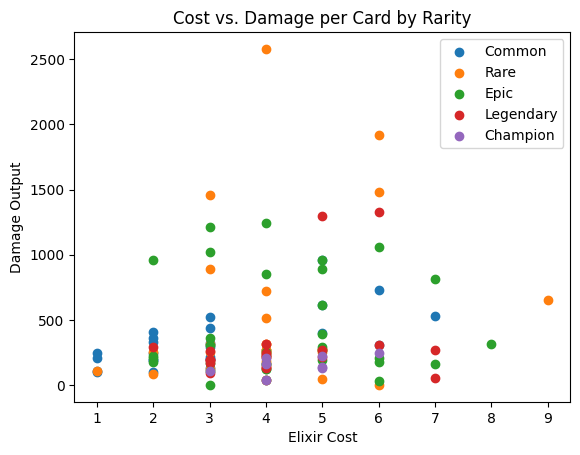

In [48]:
# Graphing bivariate relationships

rarities = ['Common', 'Rare', 'Epic', 'Legendary', 'Champion']
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['damage11'],
                label = rarities[i])
plt.title('Cost vs. Damage per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Damage Output')
plt.legend()
plt.show()

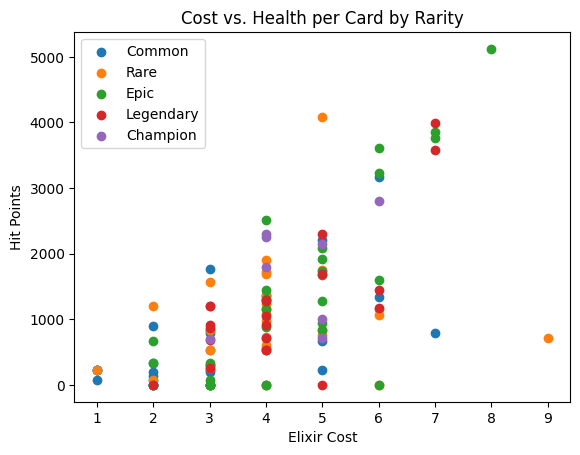

In [49]:
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['hitpoints11'],
                label = rarities[i])
plt.title('Cost vs. Health per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Hit Points')
plt.legend()
plt.show()

## Logistic Regression

### Define Binary Outcome

In [50]:
# Use median as threshold
threshold = cards['Win Rate'].median()
cards['is_high_win'] = (cards['Win Rate'] > threshold).astype(int)

print(f"\nClass distribution using median threshold ({threshold:.3f}):")
print(cards['is_high_win'].value_counts())

# Target is already created
y = cards['is_high_win']


Class distribution using median threshold (53.260):
is_high_win
0    60
1    60
Name: count, dtype: int64


### Prepare Features

In [52]:
# Features
X = cards[['elixirCost', 'damage11', 'hitpoints11', 'usage', 
           'wild_both', 'wild_evo', 'wild_hero', 
           'type_building', 'type_spell', 
           'mobility_flying', 
           'targets_both', 'targets_buildings', 
           'attack_type_splash', 
           'groupCard_True']]

### Split Train/Test

In [53]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Scale Features

In [54]:
# Scale numerical columns
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11', 'usage']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

### Train Model

In [55]:
# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Make Predictions

In [57]:
# Predict
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

### Evaluate Performance

In [58]:
# Evaluate
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.639
ROC-AUC: 0.712

Confusion Matrix:
[[17  9]
 [ 4  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72        26
           1       0.40      0.60      0.48        10

    accuracy                           0.64        36
   macro avg       0.60      0.63      0.60        36
weighted avg       0.70      0.64      0.66        36



### Interpret Coefficients

In [60]:
# Feature importance
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'odds_ratio': np.exp(log_reg.coef_[0])
})
coefficients = coefficients.sort_values('odds_ratio', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Highest to Lowest Impact)")
print("="*60)
print(coefficients.to_string(index=False))



FEATURE IMPORTANCE (Highest to Lowest Impact)
           feature  coefficient  odds_ratio
   mobility_flying     0.552426    1.737463
         wild_hero     0.366948    1.443322
    groupCard_True     0.161775    1.175596
       hitpoints11    -0.005973    0.994045
          damage11    -0.027470    0.972904
attack_type_splash    -0.141253    0.868270
             usage    -0.161576    0.850802
        elixirCost    -0.216563    0.805282
        type_spell    -0.289160    0.748893
      targets_both    -0.689966    0.501593
 targets_buildings    -0.713435    0.489958
         wild_both    -0.783304    0.456894
     type_building    -0.884476    0.412931
          wild_evo    -1.318258    0.267601


## Ridge Regression

In [61]:
# Ridge Regression with Cross-Validation
model1 = RidgeCV(alphas=[0.01, 0.1, 0.5, 1.0, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 5.0, 7.5, 10.0, 20.0, 30.0, 50.0])

# Train the model 
model1.fit(X_train_scaled, y_train)  # Use y_train, not y_sig

# Show results
print(f"Best alpha: {model1.alpha_}")
print("Coefficients:")
print(model1.coef_)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model1.coef_
})
print("\nTop 3 features increasing win rate:")
print(coef_df.sort_values('coefficient', ascending=False).head(3))
print("\nTop 3 features decreasing win rate:")
print(coef_df.sort_values('coefficient', ascending=True).head(3))

Best alpha: 7.5
Coefficients:
[-0.04272694 -0.0086249   0.00648365 -0.03221312 -0.12248243 -0.25376818
  0.06193678 -0.1482637  -0.0496509   0.09474853 -0.119815   -0.1310251
 -0.04088676  0.03464882]

Top 3 features increasing win rate:
            feature  coefficient
9   mobility_flying     0.094749
6         wild_hero     0.061937
13   groupCard_True     0.034649

Top 3 features decreasing win rate:
              feature  coefficient
5            wild_evo    -0.253768
7       type_building    -0.148264
11  targets_buildings    -0.131025


## Lasso Regression

In [63]:
# Lasso Regression with Cross-Validation
model2 = LassoCV(alphas=[0.01, 0.025, 0.05, 0.075, 0.1, 0.5, 1.0, 10.0], random_state=42)

# Train the model
model2.fit(X_train_scaled, y_train)  # Use scaled features and original y_train

print(f"Best alpha: {model2.alpha_}")
print("Coefficients:")
print(model2.coef_)

# See which features survive (non-zero coefficients)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model2.coef_
})
non_zero = coef_df[coef_df['coefficient'] != 0]
print(f"\nFeatures selected by Lasso: {len(non_zero)} out of {len(coef_df)}")
print(non_zero.sort_values('coefficient', ascending=False))

Best alpha: 10.0
Coefficients:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Features selected by Lasso: 0 out of 14
Empty DataFrame
Columns: [feature, coefficient]
Index: []


## Regression Results

### Logistic Regression

#### Scaling Numerical Features

In [71]:
# Scale only numerical columns, leave dummy variables as-is
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11', 'usage']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

#### 5-Fold Cross-Validation

In [ ]:
# Use l1_ratio=0 for L2 penalty (same as penalty='l2')
model1 = LogisticRegression(l1_ratio=0, random_state=42)
model1.fit(X_train_scaled, y_train)  # Changed from X_scaled to X_train_scaled

# Cross-validation with proper scoring
scores = cross_val_score(model1, X_train_scaled, y_train, scoring='accuracy', cv=5)  # Changed
print(f"Cross-validation accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

#### ROC-AUC

In [75]:
# ROC-AUC
auc_scores = cross_val_score(model1, X_train_scaled, y_train, scoring='roc_auc', cv=5)  # Changed
print(f"Cross-validation ROC-AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std()*2:.3f})")

Cross-validation ROC-AUC: 0.566 (+/- 0.176)


### Ridge Regression & Lasso Regression

#### Make Predictions

In [68]:
# Predict using scaled test data (same scaler used for training)
y_pred1 = model1.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)

#### RMSE & R²

In [69]:
print("Ridge Regression:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1)):.3f}")
print(f"  R²: {r2_score(y_test, y_pred1):.3f}")

print("\nLasso Regression:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred2)):.3f}")
print(f"  R²: {r2_score(y_test, y_pred2):.3f}")

Ridge Regression:
  RMSE: 0.481
  R²: -0.152

Lasso Regression:
  RMSE: 0.549
  R²: -0.502


#### Mean Error

In [67]:
print(f"Ridge mean error: {np.mean(y_pred1 - y_test):.5f}")
print(f"Lasso mean error: {np.mean(y_pred2 - y_test):.5f}")

Ridge mean error: 0.22366
Lasso mean error: 0.31746
